In [3]:
# Import required libraries for data manipulation, database connection, modeling, and visualization
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Connect to the SQL Server database and load the riser dataset into a pandas DataFrame
connection = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=DILLIBABU\\SQLEXPRESS;'
    'DATABASE=CFB;'
    'Trusted_Connection=yes;'
)
query = "SELECT * FROM riser"
df = pd.read_sql(query, connection)
df = df.dropna().drop_duplicates()  # Remove rows with missing values or duplicate entries

C:\Users\dilli\AppData\Local\Temp\ipykernel_2008\1608650300.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [5]:
# Define independent features and target variable, then split data into 80% training and 20% testing sets
X = df[['Ug', 'Gs', 'z', 'r/R', 'Particle_velocity', 'Solid_flux']]
y = df['Solid_holdup']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [6]:
# Initialize both Linear Regression and Random Forest Regressor models and fit them using training data
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [7]:
# Generate predictions on the test set for both models and calculate their performance evaluation metrics
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

lr_metrics = calculate_metrics(y_test, lr_pred)
rf_metrics = calculate_metrics(y_test, rf_pred)

  Metric  Linear Regression  Random Forest
     MAE           0.059518       0.009566
     MSE           0.006229       0.000531
    RMSE           0.078927       0.023052
R2 Score           0.679377       0.972650


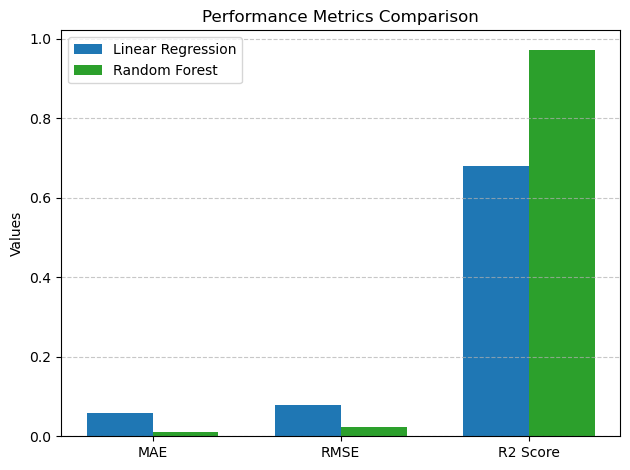

In [8]:
# Print the model performance comparison table and plot a bar chart comparing key evaluation metrics
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Linear Regression': lr_metrics,
    'Random Forest': rf_metrics
})
print(comparison_df.to_string(index=False))

metrics_to_plot = ['MAE', 'RMSE', 'R2 Score']
lr_values = [lr_metrics[0], lr_metrics[2], lr_metrics[3]]
rf_values = [rf_metrics[0], rf_metrics[2], rf_metrics[3]]
x = np.arange(len(metrics_to_plot))
width = 0.35

plt.bar(x - width/2, lr_values, width, label='Linear Regression', color='#1f77b4')
plt.bar(x + width/2, rf_values, width, label='Random Forest', color='#2ca02c')
plt.ylabel('Values')
plt.title('Performance Metrics Comparison')
plt.xticks(x, metrics_to_plot)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_performance_comparison.png')